## Plant Disease Classification with a CNN (PlantVillage)

This project follows the same flow as the class notebooks: **load the data → verify it → resize/rescale → augment → build the CNN → compile → train → evaluate → predict**. We then save the model so it can be used outside the notebook.

### Problem statement
Build a deep learning model that classifies plant leaf images into healthy or diseased classes, to help farmers spot crop problems early and decide how to protect their crops.

> **Scope note:** the brief mentions wheat, but the [PlantVillage dataset](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset) has 14 crops and 38 crop/disease classes, with no wheat class. This notebook classifies PlantVillage leaves. A wheat-specific system needs a labelled wheat dataset; the same notebook can be rerun on one. Check with your instructor if the wheat wording matters for grading.

### What we will do
1. Load PlantVillage (colour images) and check class balance and file quality
2. Split into **train / validation / test** (70 / 15 / 15, stratified)
3. Resize and rescale the images, and apply **data augmentation** to the training set only
4. Build, compile, and train a **CNN** (Conv2D + MaxPooling + Flatten + Dense)
5. Evaluate with accuracy, per-class metrics, and a confusion matrix, then look at errors
6. Save the model and make predictions on new images

> **Findings** boxes under each section summarise the results of the run recorded in this notebook (8 epochs, CPU).

### 1. Import libraries

In [1]:
# Import libraries
import os, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPUs: []


### 2. Download and prepare the PlantVillage dataset

The dataset has three versions of each image (`color`, `grayscale`, `segmented`). We use the **`color`** folder, where each sub-folder is one class (for example `Tomato___Early_blight`). Folder names become the labels.

Download it with `kagglehub`, or download and unzip it manually and set `DATA_DIR` to the `color` folder (or its parent; the cell steps into `color` for you). **Check that the cell prints 38 classes** before going on. A GPU is strongly recommended (Colab: *Runtime → Change runtime type → T4 GPU*).

> **Alternative (as in class):** TensorFlow Datasets also hosts PlantVillage: `tfds.load('plant_village', split=['train[:80%]','train[80%:90%]','train[90%:]'], with_info=True, as_supervised=True)`. It gives the same kind of `(image, label)` datasets used below, but its split is random rather than stratified, so rare classes may be thin in validation/test. This notebook builds the datasets from the Kaggle folders instead, to match the assignment.

In [2]:
DATA_DIR = r"C:\Users\User\Desktop\plantvillage dataset"

if DATA_DIR is None:
    import kagglehub
    root = Path(kagglehub.dataset_download("abdallahalidev/plantvillage-dataset"))
    DATA_DIR = next(p for p in sorted(root.rglob("color")) if p.is_dir())

DATA_DIR = Path(DATA_DIR)
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR.resolve()}")

# The download has three sub-folders (color, grayscale, segmented). We want only 'color',
# so if DATA_DIR points at the parent folder, step into 'color' automatically.
if (DATA_DIR / "color").is_dir():
    DATA_DIR = DATA_DIR / "color"
print("Using:", DATA_DIR)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
class_dirs  = sorted(p for p in DATA_DIR.iterdir() if p.is_dir())
class_names = [p.name for p in class_dirs]
num_classes = len(class_names)
print("Classes found:", num_classes)
if not all("___" in n for n in class_names):
    print("WARNING: these folder names do not look like PlantVillage classes (Crop___Disease). "
          "Check that DATA_DIR points at the 'color' folder.")
if num_classes < 2:
    raise ValueError(f"Expected one sub-folder per class in {DATA_DIR}; found {num_classes}.")

records = [(str(f), i) for i, d in enumerate(class_dirs)
           for f in d.rglob("*") if f.is_file() and f.suffix.lower() in IMAGE_EXTS]
if not records:
    raise ValueError("No supported images found.")
files  = np.array([r[0] for r in records])
labels = np.array([r[1] for r in records])
print(f"{len(files):,} images, {num_classes} classes")

Using: C:\Users\User\Desktop\plantvillage dataset\color
Classes found: 38
54,305 images, 38 classes


### 3. Verify the data

Before building anything we check three things: how many images each class has, whether every file opens, and whether the images and labels look right. Damaged files are skipped and counted rather than repaired.

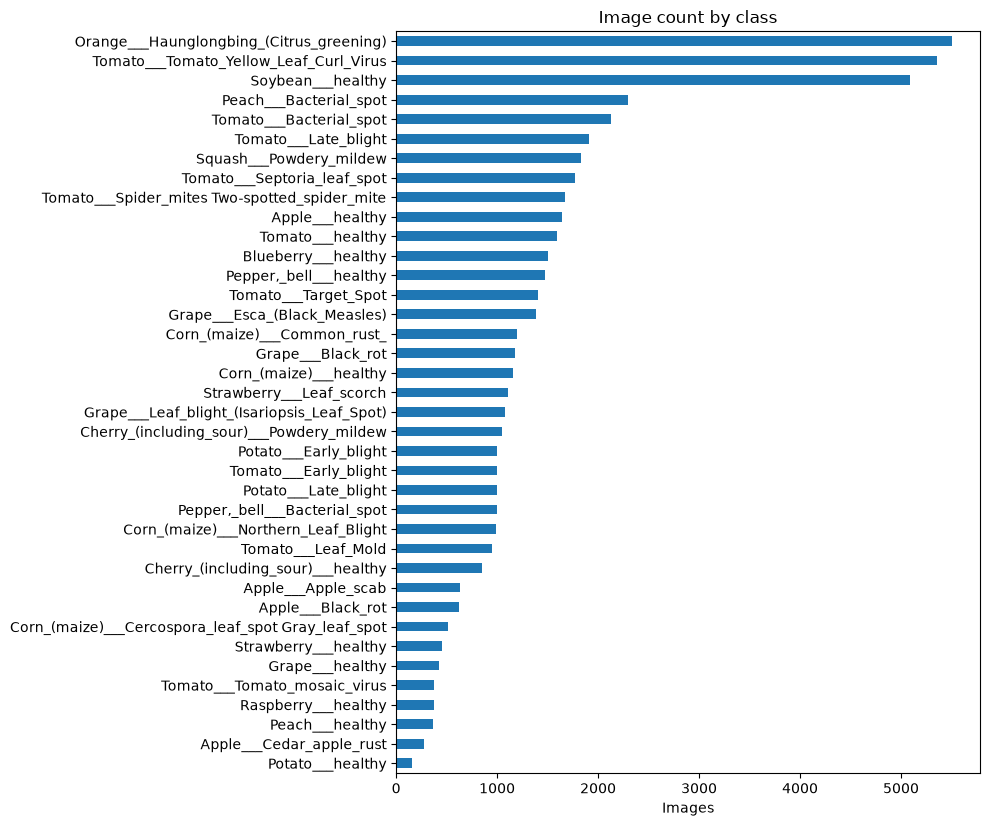

Smallest class: Potato___healthy (152)
Largest class : Orange___Haunglongbing_(Citrus_greening) (5,507)
Imbalance ratio (largest / smallest): 36.2x


In [3]:
# Class balance
counts = pd.Series(labels).value_counts().reindex(range(num_classes), fill_value=0)
class_summary = pd.DataFrame({"class": class_names, "images": counts.values})
class_summary.sort_values("images").plot.barh(x="class", y="images", legend=False,
                                              figsize=(10, max(6, num_classes * 0.22)))
plt.title("Image count by class"); plt.xlabel("Images"); plt.ylabel(""); plt.tight_layout(); plt.show()

s = class_summary["images"].sort_values()
print(f"Smallest class: {class_summary.loc[s.index[0],'class']} ({s.iloc[0]:,})")
print(f"Largest class : {class_summary.loc[s.index[-1],'class']} ({s.iloc[-1]:,})")
print(f"Imbalance ratio (largest / smallest): {s.iloc[-1]/s.iloc[0]:.1f}x")

In [4]:
# Check every file opens (can take a few minutes)
valid, bad_files = [], []
for path, label in zip(files, labels):
    try:
        with Image.open(path) as im:
            im.verify()
        valid.append((path, int(label)))
    except Exception:
        bad_files.append(path)
files  = np.array([r[0] for r in valid])
labels = np.array([r[1] for r in valid])
print("Readable images:", len(files), "| skipped corrupt/unreadable:", len(bad_files))

Readable images: 54305 | skipped corrupt/unreadable: 0


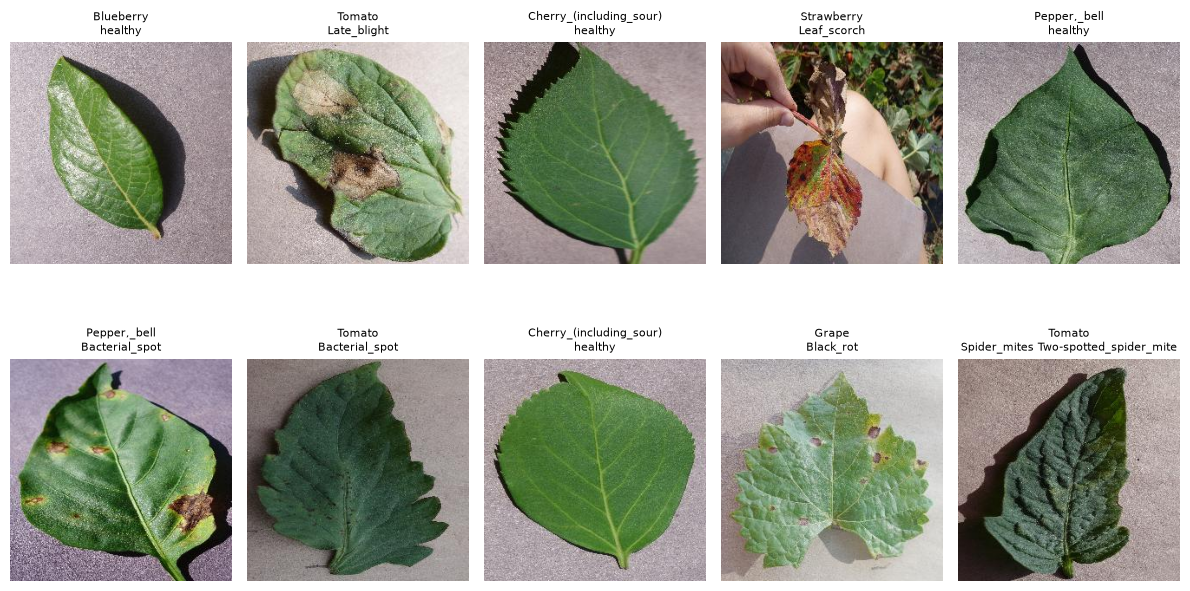

In [5]:
# Display some sample images with their class names
rng = np.random.default_rng(SEED)
plt.figure(figsize=(12, 7))
for k, idx in enumerate(rng.choice(len(files), size=10, replace=False)):
    plt.subplot(2, 5, k + 1)
    with Image.open(files[idx]) as im:
        plt.imshow(im.convert("RGB"))
    plt.title(class_names[labels[idx]].replace("___", "\n"), fontsize=8)
    plt.axis("off")
plt.tight_layout(); plt.show()

> **Findings: data.**
>
> - The dataset has **54,305 readable images in 38 classes** (14 crops); no files were corrupt.
> - It is **heavily imbalanced: 36.2×** between the largest class (Orange Huanglongbing, 5,507 images) and the smallest (Potato healthy, 152). Class size reflects how the photos were collected, not how common or important the disease is. This is why class weights (0.26 to 9.44) are used in training, and why macro F1 is reported alongside accuracy.
> - The stratified split leaves the rarest class with only **23 test images**, so its per-class scores are noisy.
> - The sample images match their labels. Nine of the ten show a single leaf, close up, on a plain grey surface. The exception is the strawberry leaf-scorch image, held in a hand with plants behind it. Controlled backgrounds make this dataset easier than real field photos, so the test scores below should be read as an **upper bound** on field performance.

### 4. Split into training, validation, and test sets

We split **70 / 15 / 15** *before* any augmentation, so no augmented copy of a training image can leak into validation or test. `stratify` keeps every class, including the rarest, in all three sets. Roles:

- **Training set:** the model learns from this.
- **Validation set:** used during training to watch for overfitting and choose when to stop.
- **Test set:** touched once at the end for the final, honest score.

Then we turn each split into a `tf.data.Dataset` of `(image, label)` pairs, the same shape of data that `tfds.load(...)` returned in class.

In [6]:
train_files, temp_files, train_y, temp_y = train_test_split(
    files, labels, test_size=0.30, random_state=SEED, stratify=labels)
val_files, test_files, val_y, test_y = train_test_split(
    temp_files, temp_y, test_size=0.50, random_state=SEED, stratify=temp_y)

for name, f in [("Train", train_files), ("Validation", val_files), ("Test", test_files)]:
    print(f"{name:<11}: {len(f):>6,} ({len(f)/len(files):.1%})")
print("Smallest class in test set:", int(np.bincount(test_y, minlength=num_classes).min()), "images")

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img, label                      # uint8 image, integer label

def make_raw_ds(paths, targets):
    ds = tf.data.Dataset.from_tensor_slices((paths, targets.astype("int32")))
    return ds.map(load_image, num_parallel_calls=AUTOTUNE)

train_ds_raw = make_raw_ds(train_files, train_y)
val_ds_raw   = make_raw_ds(val_files,   val_y)
test_ds_raw  = make_raw_ds(test_files,  test_y)      # never shuffled: order matches test_files / test_y

Train      : 38,013 (70.0%)
Validation :  8,146 (15.0%)
Test       :  8,146 (15.0%)
Smallest class in test set: 23 images


### 5. Look at one image, then resize and rescale

Let's retrieve one image from the training set to demonstrate each preprocessing step. A CNN needs every image to be the same size, and small pixel values train better than 0–255. So:

- **`Resizing`** shrinks every image to 128×128. This keeps enough detail to see leaf spots while keeping training fast.
- **`Rescaling(1./255)`** maps pixel values to the [0, 1] range.

Original shape: (256, 256, 3) | dtype: <dtype: 'uint8'>


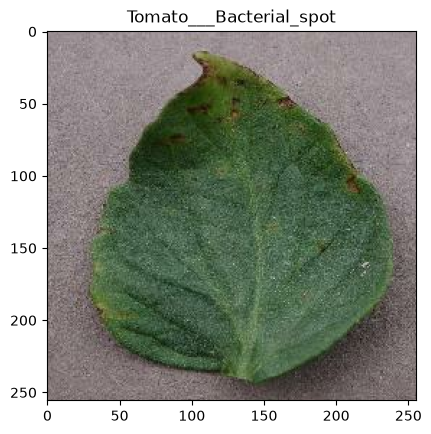

In [7]:
get_label_name = lambda i: class_names[int(i)]

image, label = next(iter(train_ds_raw))
_ = plt.imshow(image)
_ = plt.title(get_label_name(label))
print("Original shape:", image.shape, "| dtype:", image.dtype)

Min and max pixel values: 0.0 0.72058827


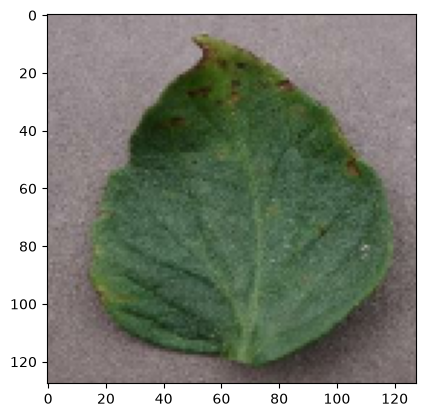

In [8]:
IMG_SIZE = 128

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1./255)
])

result = resize_and_rescale(image)
_ = plt.imshow(result)
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

### 6. Data augmentation

**Data augmentation** creates slightly modified versions of the training images (same label) so the CNN sees more variety and is less likely to memorise the training set. Real leaf photos come at different angles and lighting, so augmentation helps the model generalise.

We use Keras preprocessing layers:

| Layer | What it does | Why it suits leaves |
|---|---|---|
| `RandomFlip("horizontal_and_vertical")` | Mirrors the image | Leaves have no fixed "up" |
| `RandomRotation(0.1)` | Rotates by up to ±36° | Different camera angles |
| `RandomBrightness(0.15)` | Brightens/darkens | Sunny vs shaded photos |
| `RandomContrast(0.1)` | Changes contrast | Different cameras and lighting |

We keep the brightness and contrast changes **small**, because leaf colour (yellowing, brown spots) is the main clue to disease. Strong colour changes could make a healthy leaf look sick.

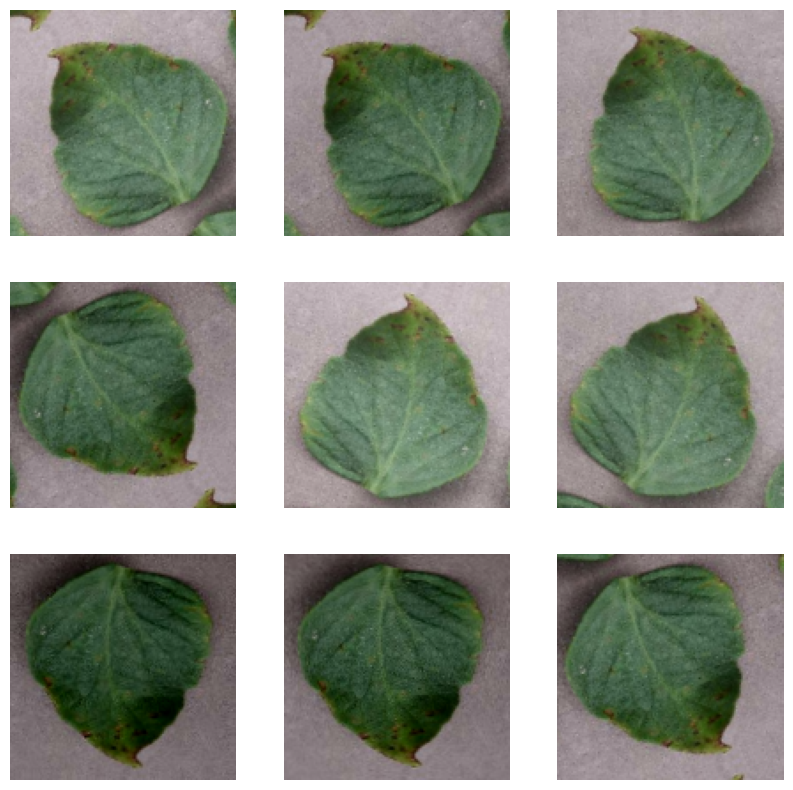

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.15, value_range=(0, 1)),
    layers.RandomContrast(0.1),
])

# Apply the layers repeatedly to the same image (training=True switches the randomness on)
image_batch = tf.expand_dims(result, 0)
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_image = data_augmentation(image_batch, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(tf.clip_by_value(augmented_image[0], 0, 1))
    plt.axis("off")
plt.show()

#### The same ideas with `tf.image`

For finer control you can use the `tf.image` functions directly. Here are a few on the same leaf, for comparison. (In training we use the Keras layers above because they apply a *random* amount each time.)

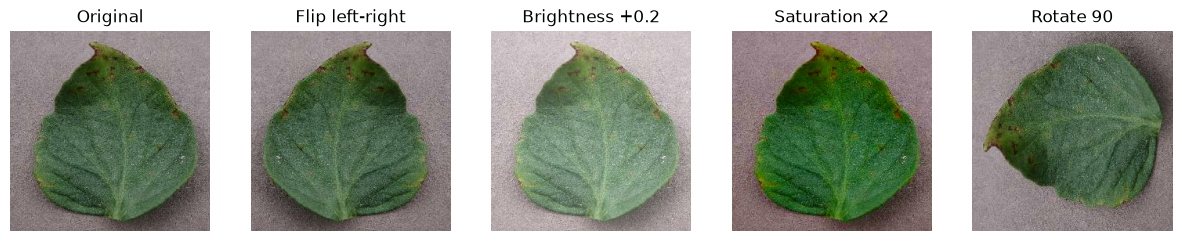

In [10]:
img01 = tf.cast(image, tf.float32) / 255.0
examples = {
    "Original":        img01,
    "Flip left-right": tf.image.flip_left_right(img01),
    "Brightness +0.2": tf.clip_by_value(tf.image.adjust_brightness(img01, 0.2), 0, 1),
    "Saturation x2":   tf.clip_by_value(tf.image.adjust_saturation(img01, 2.0), 0, 1),
    "Rotate 90":       tf.image.rot90(img01),
}
plt.figure(figsize=(15, 3.5))
for k, (title, im) in enumerate(examples.items(), start=1):
    plt.subplot(1, 5, k); plt.imshow(im); plt.title(title); plt.axis("off")
plt.show()

### 7. Prepare the datasets

We apply the preprocessing to the datasets with `.map()` (Option 2 from class), in this order:

1. **Resize and rescale** every dataset (train, validation, test)
2. **Shuffle** the training set so batches differ every epoch
3. **Batch** the data (32 images at a time)
4. **Augment the training set only.** Validation and test images must stay untouched so their scores measure real performance
5. **Prefetch** so the next batch is prepared while the current one trains

We also compute **class weights**. Some classes have far fewer images than others, and without weights the model can score well overall while ignoring rare diseases. A class weight makes mistakes on rare classes count more in the loss.

In [11]:
batch_size = 32

def prepare(ds, shuffle=False, augment=False):
    # Resize and rescale all datasets.
    ds = ds.map(lambda x, y: (resize_and_rescale(x), y), num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)

    # Batch all datasets.
    ds = ds.batch(batch_size)

    # Use data augmentation only on the training set.
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    # Use buffered prefetching on all datasets.
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds_raw, shuffle=True, augment=True)
val_ds   = prepare(val_ds_raw)
test_ds  = prepare(test_ds_raw)

weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=train_y)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print(f"Class weights range from {weights.min():.2f} to {weights.max():.2f}")

Class weights range from 0.26 to 9.44


### 8. Create the convolutional base and add Dense layers

The model uses the same pattern as the class examples: a stack of `Conv2D` and `MaxPooling2D` layers, then `Flatten`, then `Dense` layers.

- **`Conv2D(32, 3, padding='same', activation='relu')`**: learns 32 filters with a 3×3 window. Early filters pick up edges and colour patches; later layers combine them into spots, lesions, and textures. `padding='same'` keeps the width and height unchanged; ReLU adds non-linearity.
- **`MaxPooling2D()`**: halves the height and width by keeping the maximum in each 2×2 window. This cuts computation and makes the features less sensitive to exact position.
- **Four conv blocks with 32 → 64 → 128 → 256 filters**: as the image shrinks (128 → 64 → 32 → 16 → 8) the number of filters grows, so the network sees fewer positions but richer patterns. We use four blocks because disease classes are more varied than the 5 flower classes in class.
- **`Flatten()`**: turns the final 8×8×256 feature maps into one long vector for the Dense layers.
- **`Dense(128, activation='relu')`**: combines all the detected features to decide the class.
- **`Dropout(0.4)`**: randomly switches off 40% of the neurons during training, which reduces overfitting. It is inactive when predicting.
- **`Dense(num_classes)`**: one output per class. As in the class flowers example, there is no activation here: the outputs are *logits*, and the loss function applies the softmax internally (`from_logits=True`).

In [12]:
model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes)          # logits, one per class
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,490,598 (9.50 MB)

 Trainable params: 2,490,598 (9.50 MB)

 Non-trainable params: 0 (0.00 B)

> **Findings: architecture.**
>
> - The model has **2,490,598 parameters**, all trainable.
> - Most of them sit in one layer: the `Dense(128)` after `Flatten` holds **2,097,280 (about 84%)**, because Flatten produces 16,384 values (8×8×256). The four convolutional layers together hold only 388,416 (about 16%).
> - The feature map shrinks from 128×128 to 64, 32, 16, and finally 8×8 through four max-pooling steps, while the filters grow from 32 to 256. Early layers see fine detail (edges, colour patches); later layers see larger patterns such as lesions.
> - The trade-off: `Flatten` keeps the spatial layout, which is useful, but it makes the dense layer large and prone to overfitting. Global average pooling would cut the parameters sharply (see next steps).

### 9. Compile the model

- **Optimizer: Adam**, which adapts the learning rate per weight and is the usual choice for CNNs.
- **Loss: `SparseCategoricalCrossentropy(from_logits=True)`**. Our labels are plain integers (0 to 37), so we use the *sparse* version instead of one-hot encoding the labels as with CIFAR-10.
- **Metric: accuracy**.

In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

### 10. Train the model

We train for up to 20 epochs. Two callbacks keep training sensible:

- **`EarlyStopping`** stops when the validation loss has not improved for 4 epochs and **restores the best weights**, so the final model is the best one, not just the last one.
- **`ReduceLROnPlateau`** halves the learning rate if validation loss stalls for 2 epochs, so training can make finer progress.

Validation data is used only to monitor training; the model never learns from it.

In [14]:
EPOCHS = 8

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

t0 = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)
print(f"Training finished in {(time.time() - t0) / 60:.1f} min")

Epoch 1/8


c:\Users\User\Desktop\Machine learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 773s 645ms/step - accuracy: 0.2148 - loss: 2.8786 - val_accuracy: 0.5241 - val_loss: 1.6696 - learning_rate: 0.0010
Epoch 2/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 785s 631ms/step - accuracy: 0.4905 - loss: 1.7093 - val_accuracy: 0.7072 - val_loss: 0.9921 - learning_rate: 0.0010
Epoch 3/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 758s 636ms/step - accuracy: 0.5990 - loss: 1.2904 - val_accuracy: 0.7685 - val_loss: 0.7199 - learning_rate: 0.0010
Epoch 4/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 796s 632ms/step - accuracy: 0.6761 - loss: 1.0266 - val_accuracy: 0.8220 - val_loss: 0.5640 - learning_rate: 0.0010
Epoch 5/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 845s 667ms/step - accuracy: 0.7123 - loss: 0.8885 - val_accuracy: 0.8490 - val_loss: 0.4858 - learning_rate: 0.0010
Epoch 6/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 813s 676ms/step - accuracy: 0.7588 - loss: 0.7403 - val_accuracy: 0.8547 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 7/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 847s 663ms/step - accuracy:

> **Findings: training.**
>
> - Training ran for **8 epochs (106.9 minutes, about 13 minutes per epoch on CPU)**. Validation loss fell every epoch, from 1.67 to **0.32**, and validation accuracy rose from 52.4% to **90.1%**.
> - The best epoch was the **last one (epoch 8)**. Early stopping never fired and the learning rate stayed at 0.001, so training ended because the epoch budget ran out, **not because the model converged**. The curves are still sloping downward, so more epochs should improve results.
> - Training accuracy (79.2%) is **below** validation accuracy (90.1%) in the last epoch. This is expected here, not a bug: augmentation and dropout are active only during training, and the validation images are unmodified. Training loss is also class-weighted while validation loss is not, so the two loss curves are not directly comparable.
> - There is **no sign of overfitting**: validation and training metrics improve together.

### 11. Evaluate the model

First the learning curves, then the score on the **test set**, which the model has never seen.

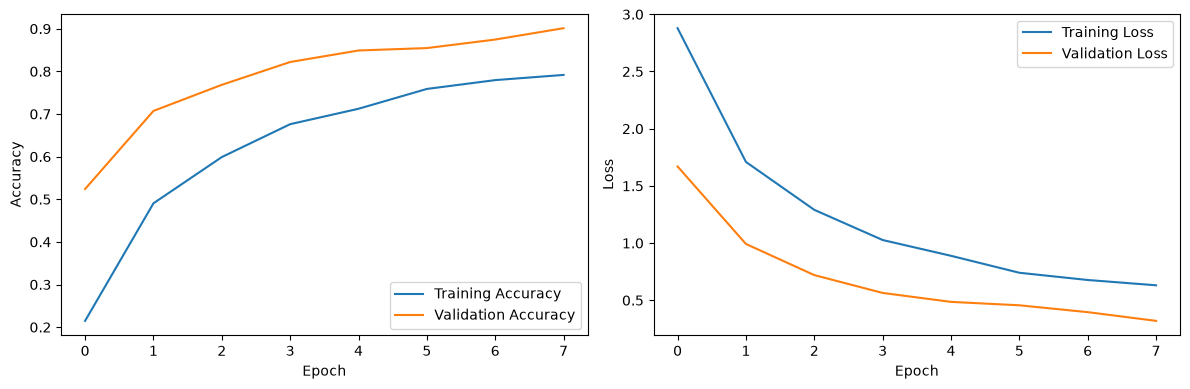

255/255 - 43s - 168ms/step - accuracy: 0.9006 - loss: 0.2993
Test Accuracy: 0.9006


In [15]:
# Plot training & validation accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set(xlabel='Epoch', ylabel='Accuracy'); axes[0].legend(loc='lower right')
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set(xlabel='Epoch', ylabel='Loss'); axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f'Test Accuracy: {test_acc:.4f}')

255/255 ━━━━━━━━━━━━━━━━━━━━ 44s 170ms/step


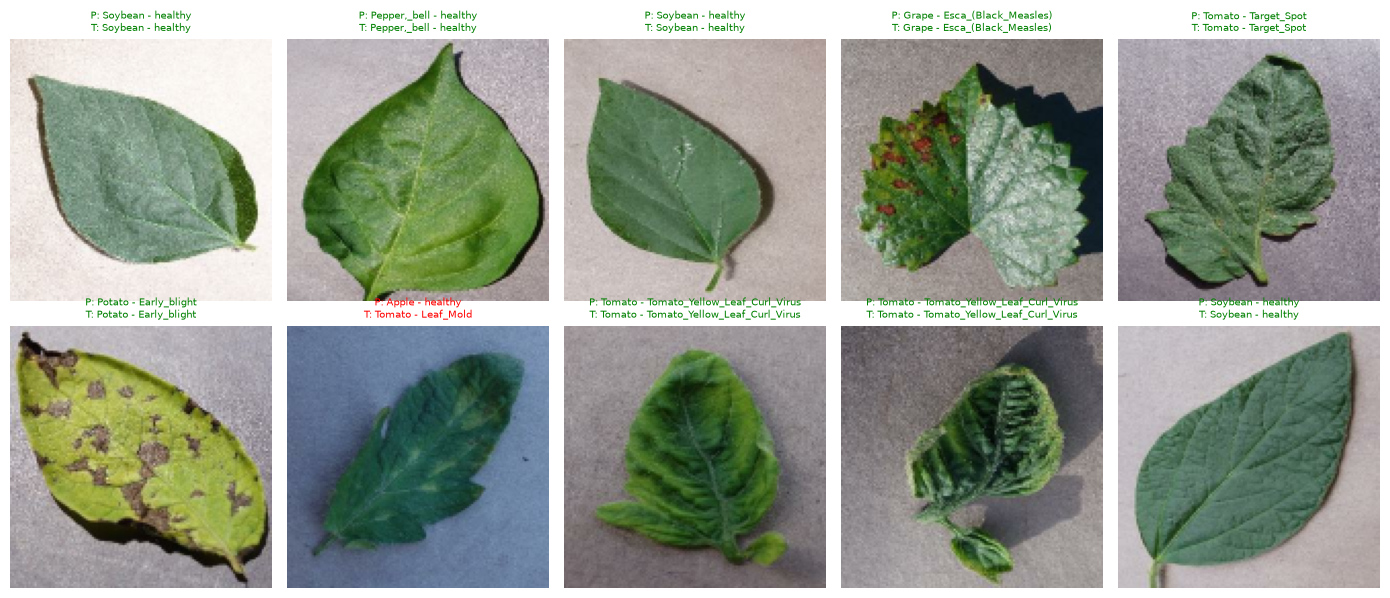

In [16]:
# Make predictions on the whole test set (the model outputs logits, so apply softmax for probabilities)
logits = model.predict(test_ds)
y_prob = tf.nn.softmax(logits).numpy()
y_pred = y_prob.argmax(axis=1)
y_true = test_y

# Display some test images with predicted and true labels (green = correct, red = wrong)
images, _ = next(iter(test_ds))
plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    ok = y_pred[i] == y_true[i]
    plt.title(f"P: {class_names[y_pred[i]]}\nT: {class_names[y_true[i]]}".replace("___", " - "),
              fontsize=7, color="green" if ok else "red")
    plt.axis('off')
plt.tight_layout(); plt.show()

Accuracy alone can hide problems: with 38 uneven classes, a model can look good overall while failing on a few. So we also look at **precision, recall, and F1 per class**.

- **Precision:** when the model says "late blight", how often is it right?
- **Recall:** of all the real late blight leaves, how many did it find? (For farmers, missed disease is usually the costlier error.)
- **F1:** a single score balancing the two. **Macro F1** averages it across classes equally, so rare classes count as much as common ones.

In [17]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0, digits=3))

report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
macro_f1 = report["macro avg"]["f1-score"]
print(f"Test accuracy: {test_acc:.4f} | macro F1: {macro_f1:.4f}")

per_class = pd.DataFrame(report).T.iloc[:num_classes]
per_class.sort_values("f1-score").head(10).round(3)      # the 10 weakest classes

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.791     0.766     0.778        94
                                 Apple___Black_rot      0.926     0.946     0.936        93
                          Apple___Cedar_apple_rust      0.645     0.976     0.777        41
                                   Apple___healthy      0.910     0.736     0.813       246
                               Blueberry___healthy      0.986     0.965     0.975       226
                 Cherry_(including_sour)___healthy      0.925     0.961     0.943       128
          Cherry_(including_sour)___Powdery_mildew      0.925     0.937     0.931       158
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.806     0.649     0.719        77
                       Corn_(maize)___Common_rust_      0.978     0.989     0.983       179
                            Corn_(maize)___healthy      1.000     0.983     0.9

,precision,recall,f1-score,support
Potato___healthy,0.358,0.826,0.500,23.0
Tomato___Early_blight,0.636,0.747,0.687,150.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.806,0.649,0.719,77.0
Apple___Cedar_apple_rust,0.645,0.976,0.777,41.0
Apple___Apple_scab,0.791,0.766,0.778,94.0
Tomato___Late_blight,0.878,0.703,0.781,286.0
Peach___healthy,0.659,1.000,0.794,54.0
Tomato___Septoria_leaf_spot,0.852,0.756,0.801,266.0
Apple___healthy,0.910,0.736,0.813,246.0
Grape___healthy,0.726,0.953,0.824,64.0


> **Findings: test performance.**
>
> - On the unseen test set (8,146 images): **accuracy 90.06%, macro F1 0.872, weighted F1 0.902**. Validation accuracy was 90.13%, so the test score confirms the validation result.
> - Macro F1 is below accuracy because the weakest classes are the small ones, and macro F1 counts every class equally. Accuracy is pulled up by large classes such as Orange Huanglongbing, Soybean healthy, and Tomato yellow leaf curl virus.
> - **Strong classes:** 9 of 38 reach F1 ≥ 0.95 (best: Corn healthy 0.991, Corn common rust 0.983, Blueberry healthy 0.975), and 18 reach ≥ 0.90.
> - **Weak classes:** 7 fall below F1 0.80 and 2 below 0.70: Potato healthy (0.500), Tomato early blight (0.687), Corn Cercospora/gray leaf spot (0.719), Apple cedar apple rust (0.777), Apple scab (0.778), Tomato late blight (0.781), and Peach healthy (0.794).
> - **Precision vs recall differ by class size.** The ten classes with fewer than 100 test images average precision 0.754 but recall 0.891, while the larger classes average 0.896 and 0.901. Potato healthy (precision 0.358, recall 0.826) and Peach healthy (0.659, 1.000) show this clearly: the model finds almost all of them but also labels many other leaves as these classes. This is consistent with the class weights, which push the model toward rare classes at a cost to their precision.
> - Potato healthy has only 23 test images, so its F1 can swing a lot with a few errors. Treat it as an indication, not a precise measurement.

### 12. Error analysis

The **confusion matrix** shows which classes get mixed up (rows are the true class, columns the predicted class). We also list the most frequent confusions and look at some misclassified images.

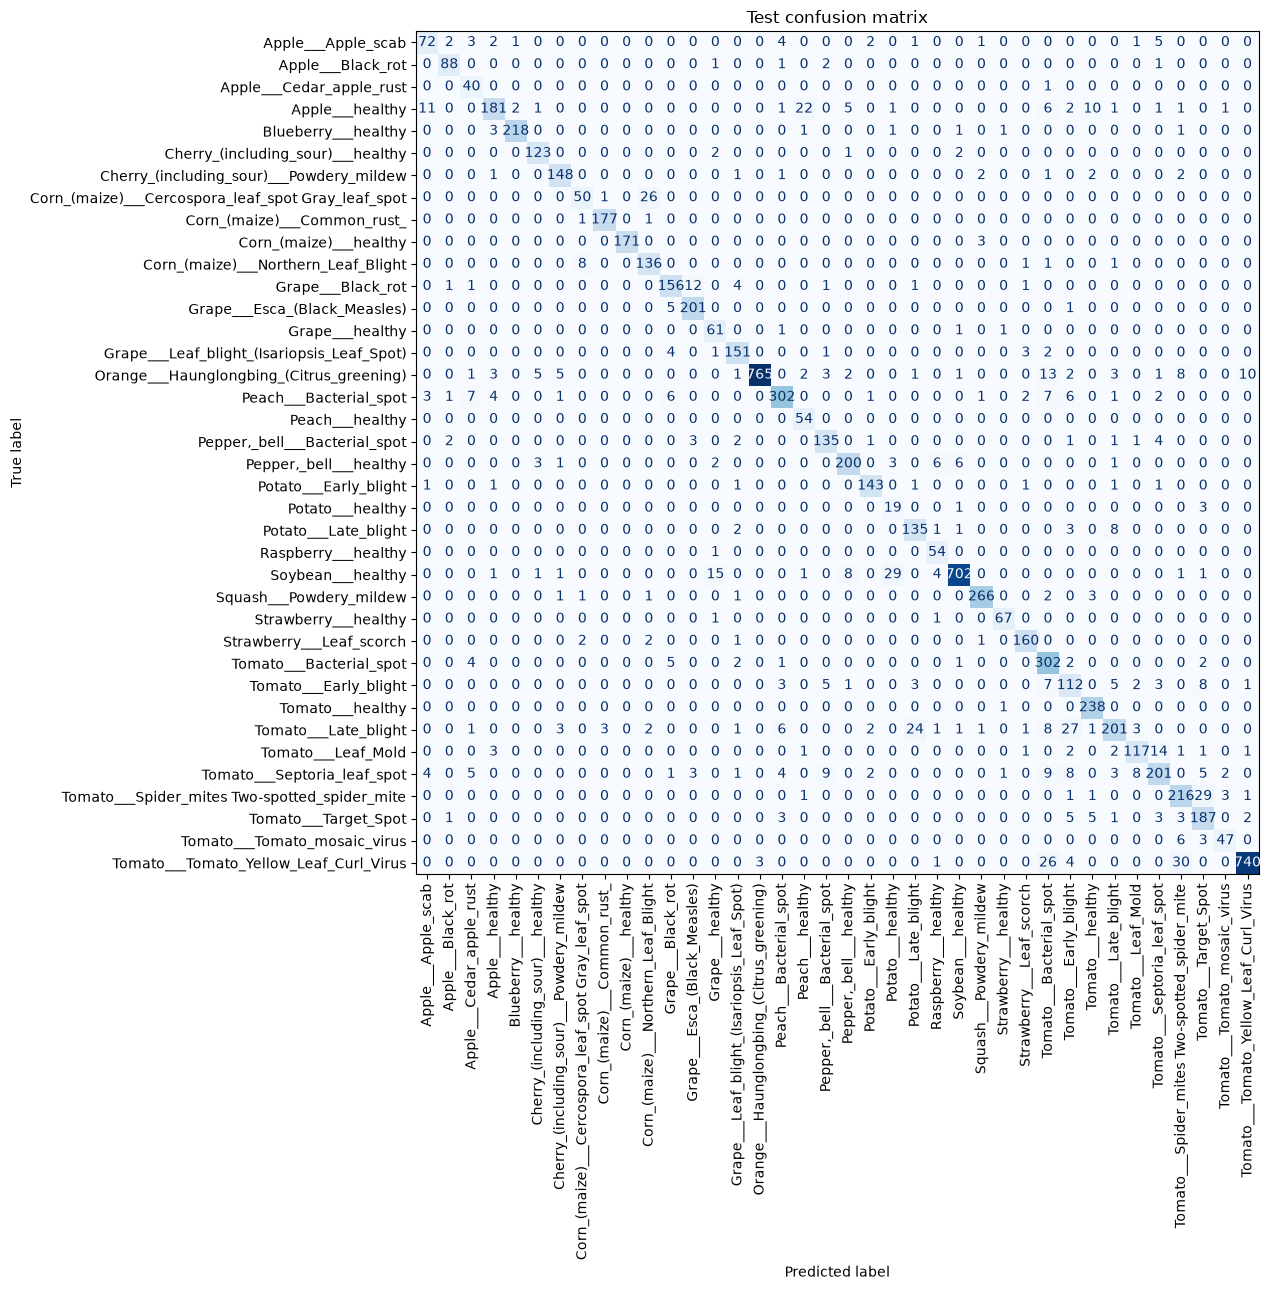

,count,true class,predicted as
0,30,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Spider_mites Two-spotted_spider_mite
1,29,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot
2,29,Soybean___healthy,Potato___healthy
3,27,Tomato___Late_blight,Tomato___Early_blight
4,26,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Bacterial_spot
5,26,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight
6,24,Tomato___Late_blight,Potato___Late_blight
7,22,Apple___healthy,Peach___healthy
8,15,Soybean___healthy,Grape___healthy
9,14,Tomato___Leaf_Mold,Tomato___Septoria_leaf_spot


In [18]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(15, 13))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False, values_format="d")
plt.title("Test confusion matrix"); plt.tight_layout(); plt.show()

# Most frequent confusions (ignoring the diagonal)
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted(((off[i, j], class_names[i], class_names[j]) for i, j in zip(*np.nonzero(off))), reverse=True)
pd.DataFrame(pairs[:10], columns=["count", "true class", "predicted as"])

Misclassified test images: 810 of 8146 (9.9%)


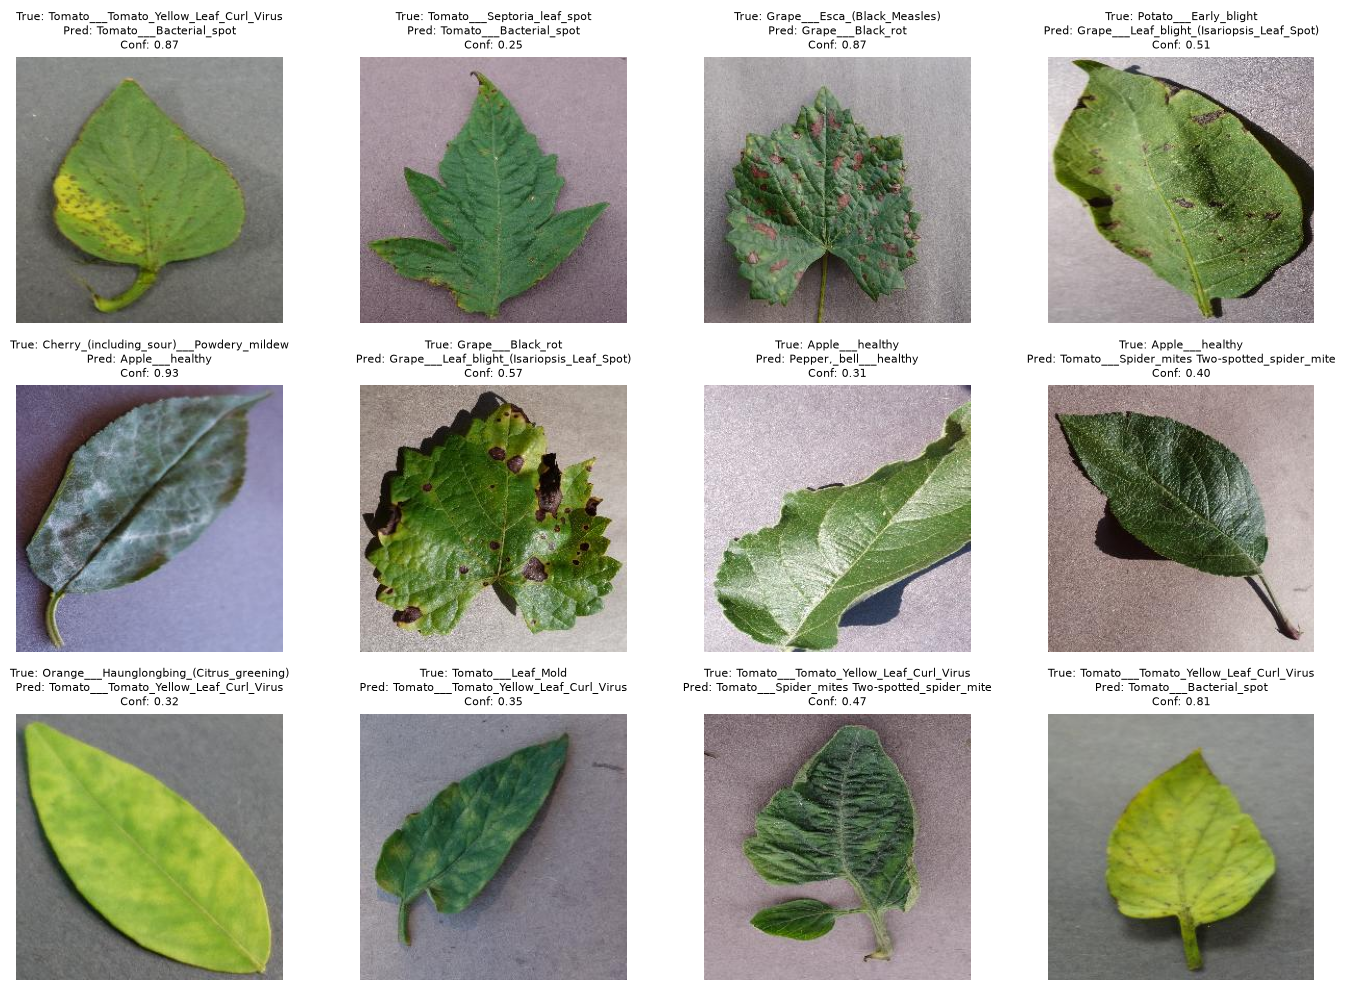

In [19]:
mis_idx = np.flatnonzero(y_true != y_pred)
print(f"Misclassified test images: {len(mis_idx)} of {len(y_true)} ({len(mis_idx)/len(y_true):.1%})")

conf = y_prob.max(axis=1)
show = np.random.default_rng(SEED).choice(mis_idx, size=min(12, len(mis_idx)), replace=False)
plt.figure(figsize=(14, 10))
for k, i in enumerate(show):
    plt.subplot(3, 4, k + 1)
    with Image.open(test_files[i]) as im:
        plt.imshow(im.convert("RGB"))
    plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}\nConf: {conf[i]:.2f}", fontsize=8)
    plt.axis("off")
plt.tight_layout(); plt.show()

> **Findings: errors.**
>
> - **810 of 8,146 test images (9.9%) were misclassified.** The ten most common confusions add up to 242 errors, about 30% of all mistakes. The rest are spread over many other pairs, which points to a general under-training / fine-grained difficulty problem rather than one bad class or label.
> - **Tomato dominates.** Six of the top ten confusions have a tomato class as the true label: yellow leaf curl virus → spider mites (30) and → bacterial spot (26), spider mites → target spot (29), late blight → early blight (27), late blight → *potato* late blight (24), and leaf mold → Septoria leaf spot (14). These are diseases with similar spots, blotches, or yellowing, and tomato has the most classes of any crop here. Tomato late blight → Potato late blight is a same-disease, different-crop confusion.
> - **Corn Cercospora/gray leaf spot → Northern leaf blight (26)** is another look-alike pair; it explains that class's low recall (0.649).
> - **Healthy leaves of different crops get mixed up:** Soybean healthy → Potato healthy (29), Apple healthy → Peach healthy (22), Soybean healthy → Grape healthy (15). Healthy leaves have no lesions to learn from, so the model relies on shape and colour, which it has not yet learned well after 8 epochs.
> - **Confidence is a mixed signal.** Among the 12 misclassified images shown, 4 were predicted with confidence of 0.81 or higher (for example a cherry leaf with powdery mildew called "Apple healthy" at 0.93), while 8 were below 0.60. High-confidence mistakes mean the probability cannot be trusted on its own.
> - **The costliest error for a farmer is a diseased leaf predicted as healthy**, like the powdery-mildew example above. The classification report's per-class recall is the number to watch for this.
> - Several wrong images have subtle or overlapping symptoms (for example light yellowing). From the images alone I cannot tell whether any labels are wrong, so label noise is a possibility to check, not a finding.

### 13. Save the model and predict on new images

For deployment we wrap the trained model so it accepts a **raw image** and returns **class probabilities**. We put the same resize and rescale layers in front of the model (Option 1 from class: preprocessing as part of the model) and add a softmax at the end. That way, whoever uses the saved file does not need to repeat any preprocessing. We then confirm the saved model gives the same answers as the one in memory.

In [20]:
inputs  = tf.keras.Input(shape=(None, None, 3), name="image")      # any image size, raw 0-255 pixels
x       = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x       = layers.Rescaling(1./255)(x)
x       = model(x)
outputs = layers.Softmax()(x)
export_model = tf.keras.Model(inputs, outputs, name="plant_disease_cnn")

MODEL_PATH = Path("plant_disease_cnn.keras")
export_model.save(MODEL_PATH)
with open("class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("Saved:", MODEL_PATH, f"({MODEL_PATH.stat().st_size/1e6:.1f} MB) and class_names.json")

# Reload and confirm it matches the probabilities computed earlier on the same test images
reloaded = tf.keras.models.load_model(MODEL_PATH)
raw_batch = np.stack([img.numpy() for img, _ in test_ds_raw.take(8)]).astype("float32")
diff = np.abs(reloaded.predict(raw_batch, verbose=0) - y_prob[:8]).max()
print("Max probability difference after reload:", diff)

Saved: plant_disease_cnn.keras (30.0 MB) and class_names.json
Max probability difference after reload: 4.656613e-09


In [21]:
def predict_image(path_or_pil, top_k=3):
    im = path_or_pil if isinstance(path_or_pil, Image.Image) else Image.open(path_or_pil)
    arr = np.array(im.convert("RGB"), dtype="float32")[None]
    probs = reloaded.predict(arr, verbose=0)[0]
    top = probs.argsort()[::-1][:top_k]
    return [(class_names[i], round(float(probs[i]), 3)) for i in top]

print("True label:", class_names[test_y[0]])
predict_image(test_files[0])

True label: Soybean___healthy


[('Soybean___healthy', 0.999),
 ('Pepper,_bell___healthy', 0.001),
 ('Grape___healthy', 0.0)]

### 14. Deployment: a simple web app

The cell below writes `app.py`, a small [Gradio](https://www.gradio.app/) app: a farmer uploads a leaf photo and sees the top-3 predictions with confidence.

**Run it locally**

```bash
pip install tensorflow gradio pillow
# keep these three files in one folder: app.py, plant_disease_cnn.keras, class_names.json
python app.py          # open the URL it prints, usually http://127.0.0.1:7860
```

To share it online for free, upload the three files plus a `requirements.txt` (`tensorflow`, `gradio`, `pillow`) to a [Hugging Face Space](https://huggingface.co/spaces) using the Gradio SDK.

In [22]:
APP_CODE = '''
import json
import numpy as np
import gradio as gr
import tensorflow as tf

model = tf.keras.models.load_model("plant_disease_cnn.keras")
class_names = json.load(open("class_names.json"))

def predict(image):
    if image is None:
        return {}
    arr = np.array(image.convert("RGB"), dtype="float32")[None]
    probs = model.predict(arr, verbose=0)[0]
    return {class_names[i].replace("___", " - "): float(probs[i]) for i in probs.argsort()[::-1][:3]}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Leaf photo"),
    outputs=gr.Label(num_top_classes=3, label="Predicted condition"),
    title="Plant Disease Classifier",
    description="Upload a clear photo of a single leaf. Trained on PlantVillage (38 classes); "
                "accuracy on real field photos may be lower than on the test set.",
)

if __name__ == "__main__":
    demo.launch()
'''
Path("app.py").write_text(APP_CODE.strip() + "\n")
print("Wrote app.py")

Wrote app.py


### 15. Summary and conclusions

In [23]:
print(f"Dataset         : PlantVillage (color), {len(files):,} images, {num_classes} classes")
print(f"Split           : {len(train_files):,} / {len(val_files):,} / {len(test_files):,} (train / val / test)")
print(f"Model           : 4-block CNN (Conv2D + MaxPooling) + Flatten + Dense, {model.count_params():,} parameters")
print(f"Training        : {len(history.epoch)} of {EPOCHS} epochs run, best-val-loss weights restored")
print(f"Best val loss   : {min(history.history['val_loss']):.4f}")
print(f"Test accuracy   : {test_acc:.4f}")
print(f"Test macro F1   : {macro_f1:.4f}")

Dataset         : PlantVillage (color), 54,305 images, 38 classes
Split           : 38,013 / 8,146 / 8,146 (train / val / test)
Model           : 4-block CNN (Conv2D + MaxPooling) + Flatten + Dense, 2,490,598 parameters
Training        : 8 of 8 epochs run, best-val-loss weights restored
Best val loss   : 0.3198
Test accuracy   : 0.9006
Test macro F1   : 0.8720


> **Conclusions.**
>
> - **What worked:** a 2.5M-parameter CNN trained from scratch for only 8 epochs on CPU reached **90.06% test accuracy and macro F1 0.872** across 38 classes, with validation and test scores in agreement and no overfitting. Augmentation, class weights, and the stratified split kept the results fair across crops and rare classes.
> - **Where it struggles:** look-alike tomato diseases (blights, spider mites, target spot, leaf mold vs Septoria), Corn Cercospora vs Northern leaf blight, and healthy leaves of different crops. Rare classes such as Potato healthy have high recall but low precision, a side effect of heavy class weighting.
> - **Limitations:**
>   - Training stopped by the 8-epoch budget while validation loss was still falling, so these numbers are **not the best this model can do**.
>   - PlantVillage photos are clean, mostly single-leaf images on plain backgrounds. The model may rely on those conditions, so field accuracy is likely lower than 90%.
>   - Rare classes have few test images (as few as 23), so their scores are noisy.
>   - This is a single run with one random seed, so small differences between runs are expected.
>   - Several images may come from the same physical leaf, and a random split can place them in both train and test, which can inflate scores slightly. I have not checked this in the data.
>   - The dataset has no wheat, so this model cannot diagnose wheat.
> - **Next steps:**
>   1. Train longer (for example 30 epochs on a GPU such as Colab) and let early stopping decide when to stop.
>   2. Replace `Flatten` with global average pooling and add BatchNorm to reduce the 2.1M-parameter dense layer.
>   3. Soften the class weights (for example the square root) to recover precision on rare classes.
>   4. Compare against transfer learning (MobileNetV2 or EfficientNet).
>   5. Test on real field photos (for example the PlantDoc dataset) and add a "not sure" confidence threshold, since high-confidence errors occur.
>   6. For wheat, source a labelled wheat-disease dataset (rust, powdery mildew, septoria) and rerun this notebook.